# Spam Email Detection

In [1]:
# Importing Libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score


# Data Collection
df = pd.read_csv("Spam_Email_Detection.csv")
display(df.head(5))
display(df.info())
display(df.describe())


# Data Cleaning 
encoder = LabelEncoder()
df["Category"] = encoder.fit_transform(df["Category"])

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z ]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

df["Message"] = df["Message"].apply(clean_text)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Category  5572 non-null   str  
 1   Message   5572 non-null   str  
dtypes: str(2)
memory usage: 87.2 KB


None

,Category,Message
count,5572,5572
unique,2,5157
top,ham,"Sorry, I'll call later"
freq,4825,30


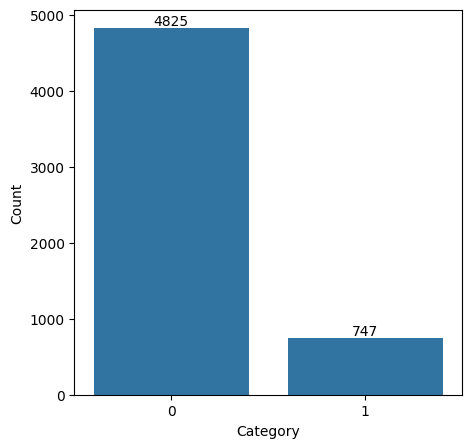

In [2]:
# Data Visualization
plt.figure(figsize=(5, 5))
ax = sns.countplot(data=df, x="Category")
for container in ax.containers:
    ax.bar_label(container)

plt.xlabel("Category")
plt.ylabel("Count")
plt.show()

In [3]:
# Train Test Split
vectorizer = TfidfVectorizer(stop_words='english')
X = vectorizer.fit_transform(df["Message"])
y = df["Category"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# Model Training
model = MultinomialNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)


# Model Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.9632286995515695


In [5]:
# Model Deployment
email = ["Congratulations! You have won a free iPhone. Click now!"]
email = vectorizer.transform(email)
prediction = model.predict(email)
print("Spam Email" if prediction[0] == 1 else "Not Spam Email")

Spam Email
